In [ ]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [6]:
import pandas as pd
dataset = pd.read_csv("../datasets/AraPoems_Dataset.csv")

In [7]:
list_of_requierd = ["قصائد غزل","قصائد هجاء","قصائد مدح","قصائد رثاء"]

In [8]:
da = dataset[dataset['type_ar'].isin( list_of_requierd)]

In [9]:
da2 = pd.DataFrame()
da2["poem"] = da["first_hemistich"]+" "+da["second_hemistich"]
da2["type"] = da["type_ar"]

In [85]:
df_sampled = da2.groupby('type').head(1000)
# df_sampled_rest = da2.groupby("type").head(10000)[250:]

In [86]:
df_sampled = df_sampled.dropna()

In [87]:
df_sampled["type"].value_counts()

type
قصائد رثاء    1000
قصائد غزل     1000
قصائد مدح     1000
قصائد هجاء     997
Name: count, dtype: int64

In [88]:
df_sampled11 = da2.groupby('type').head(700)
df_sampled11 = df_sampled11[300:]

In [89]:
df_sampled11["type"].value_counts()

type
قصائد هجاء    672
قصائد غزل     635
قصائد مدح     604
قصائد رثاء    589
Name: count, dtype: int64

In [ ]:
# import numpy as np
# import tensorflow as tf
# from transformers import AutoTokenizer, AutoModel
# import torch

# class EmbeddingGenerator:
#     """
#     Generate embeddings for Arabic texts
#     """
#     def __init__(self, model_name="../akhooli"):
#         self.tokenizer = AutoTokenizer.from_pretrained(model_name)
#         self.tokenizer.pad_token = self.tokenizer.eos_token
#         self.model = AutoModel.from_pretrained(model_name)
#         self.model.eval()
#         self.embedding_dim = 768
    
#     def get_sentence_embedding(self, text, pooling='cls'):
#         """
#         Get embedding for a single sentence
#         """
#         inputs = self.tokenizer(
#             text,
#             return_tensors='pt',
#             padding=True,
#             truncation=True,
#             # max_length=128
#         )
        
#         with torch.no_grad():
#             outputs = self.model(**inputs)
        
#         if pooling == 'mean':
#             embedding = outputs.last_hidden_state.mean(dim=1).numpy()[0]
#         elif pooling == 'cls':
#             embedding = outputs.last_hidden_state[:, 0, :].numpy()[0]
        
#         return embedding
    
#     def get_batch_embeddings(self, texts, pooling='mean'):
#         """
#         Get embeddings for multiple sentences
#         Returns: numpy array of shape (n_samples, embedding_dim)
#         """
#         embeddings = []
#         for text in texts:
#             emb = self.get_sentence_embedding(text, pooling)
#             embeddings.append(emb)
        
#         return np.array(embeddings)

2026-02-17 20:30:38.407347: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-17 20:30:38.434799: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 20:30:39.279887: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# eg = EmbeddingGenerator()

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 2701.41it/s, Materializing param=wte.weight]             
GPT2Model LOAD REPORT from: ../akhooli
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# # ====================================================
# # ARAPOEMBERT - Poetry-Specific Classification
# # For 4-Class Arabic Poetry Classification
# # ====================================================

# # @title 1. Install Dependencies
# # !pip install -q transformers datasets torch pandas sklearn accelerate

# import torch
# import numpy as np
# import pandas as pd
# from transformers import (
#     AutoTokenizer, 
#     AutoModelForSequenceClassification,
#     Trainer, 
#     TrainingArguments,
#     DataCollatorWithPadding
# )
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # @title 2. Load Your Data
# # Replace with your actual data
# # df = pd.read_csv('your_poetry_data.csv')
# # texts = df['text'].tolist()
# # labels = df['label'].tolist()  # 0, 1, 2, 3

# # Example data structure (replace with your real data)
# texts = [
#     "ألا ليت شعري هل أبيتن ليلة - وقد طال ما بيني وبينكم عمري",
#     "إذا المرء لم يدنس من اللؤم عرضه - فكل رداء يرتديه جميل",
#     "وما نيل المطالب بالتمني - ولكن تؤخذ الدنيا غلابا",
#     "على قدر أهل العزم تأتي العزائم - وتأتي على قدر الكرام المكارم",
# ] * 100  # Creates 400 samples

# labels = [0, 1, 2, 3] * 100  # 400 labels

# print(f"Total samples: {len(texts)}")
# print(f"Class distribution: {np.bincount(labels)}")

# # Split data
# train_texts, val_texts, train_labels, val_labels = train_test_split(
#     texts, labels, test_size=0.2, random_state=42, stratify=labels
# )

# print(f"Train: {len(train_texts)} samples")
# print(f"Validation: {len(val_texts)} samples")

Total samples: 400
Class distribution: [100 100 100 100]
Train: 320 samples
Validation: 80 samples


In [ ]:
# # @title 3. Load AraPoemBERT
# model_name = "../akhooli"  # The poetry-specific model

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# tokenizer.pad_token = tokenizer.eos_token
# # Load model with classification head
# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=4,  # Your 4 poetry classes
#     ignore_mismatched_sizes=True  # Important for new head
# )

# print(f"Model loaded: {model_name}")
# print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 2083.42it/s, Materializing param=transformer.wte.weight]             
GPT2ForSequenceClassification LOAD REPORT from: ../akhooli
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED | 
lm_head.weight                          | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: ../akhooli
Parameters: 368,900,096


In [ ]:
# # @title 4. Create Dataset
# class PoetryDataset(torch.utils.data.Dataset):
#     def __init__(self, texts, labels, tokenizer, max_length=256):
#         self.texts = texts
#         self.labels = labels
#         self.tokenizer = tokenizer
#         self.max_length = max_length
    
#     def __len__(self):
#         return len(self.texts)
    
#     def __getitem__(self, idx):
#         text = str(self.texts[idx])
#         label = self.labels[idx]
        
#         encoding = self.tokenizer(
#             text,
#             truncation=True,
#             padding='max_length',
#             max_length=self.max_length,
#             return_tensors='pt'
#         )
        
#         return {
#             'input_ids': encoding['input_ids'].squeeze(0),
#             'attention_mask': encoding['attention_mask'].squeeze(0),
#             'labels': torch.tensor(label, dtype=torch.long)
#         }

# # Create datasets
# train_dataset = PoetryDataset(train_texts, train_labels, tokenizer, max_length=256)
# val_dataset = PoetryDataset(val_texts, val_labels, tokenizer, max_length=256)

In [ ]:
# # @title 5. Handle Class Imbalance (If Needed)
# from sklearn.utils.class_weight import compute_class_weight
# import torch.nn as nn

# # Compute class weights
# class_weights = compute_class_weight(
#     'balanced',
#     classes=np.unique(train_labels),
#     y=train_labels
# )
# class_weights = torch.tensor(class_weights, dtype=torch.float)

# # Custom Trainer with weighted loss
# class WeightedTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False):
#         labels = inputs.get("labels")
#         outputs = model(**inputs)
#         logits = outputs.get('logits')
        
#         loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
#         loss = loss_fct(logits, labels)
        
#         return (loss, outputs) if return_outputs else loss

In [ ]:
# # @title 6. Define Metrics
# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred
#     predictions = np.argmax(predictions, axis=1)
    
#     return {
#         'accuracy': accuracy_score(labels, predictions),
#         'f1_macro': f1_score(labels, predictions, average='macro'),
#         'f1_weighted': f1_score(labels, predictions, average='weighted'),
#         'f1_micro': f1_score(labels, predictions, average='micro')
#     }

In [ ]:
# # @title 7. Training Arguments
# training_args = TrainingArguments(
#     output_dir='./arapoembert-results',
#     num_train_epochs=5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     warmup_ratio=0.1,
#     weight_decay=0.01,
#     logging_dir='./logs',
#     logging_steps=10,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     metric_for_best_model='f1_weighted',
#     greater_is_better=True,
#     save_total_limit=2,
#     dataloader_drop_last=True,
#     fp16=True,  # Mixed precision for speed
# )

# # Data collator
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# # @title 8. Train
# # Use WeightedTrainer if you have imbalance, otherwise regular Trainer
# trainer = WeightedTrainer(  # or Trainer if no imbalance
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )

# print("Starting training...")
# trainer.train()

Starting training...


TypeError: WeightedTrainer.compute_loss() got an unexpected keyword argument 'num_items_in_batch'

In [90]:
fff = df_sampled['type'].astype('category').cat.codes

In [91]:
fff.value_counts()

0    1000
1    1000
2    1000
3     997
Name: count, dtype: int64

In [ ]:
# # ====================================================
# # COMPLETE SIMPLE FINE-TUNING - COPY AND PASTE THIS
# # ====================================================

# # 1. Install
# # !pip install -q transformers datasets pandas

# # 2. Imports
# import pandas as pd
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# from datasets import Dataset
# import numpy as np

# # 3. Your Data - REPLACE THESE WITH YOUR ACTUAL DATA
# texts = df_sampled["poem"].to_list()

# labels = fff.to_list()  # 100 labels

# # 4. Create Dataset
# train_data = Dataset.from_dict({"text": texts, "label": labels})

# # 5. Load Model and Tokenizer
# model_name = "../camel"  # Best for Arabic
# tokenizer = AutoTokenizer.from_pretrained(model_name,padding=True)
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

# # 6. Tokenize (ONE LINE)
# # train_data = train_data.map(lambda x: tokenizer(x["text"], padding=True, truncation=True), batched=True)
# train_data = train_data.map(
#     lambda x: tokenizer(
#         x["text"], 
#         padding='max_length',  # Pad to max_length
#         truncation=True, 
#         max_length=128         # Set a fixed length
#     ), 
#     batched=True
# )
# # 7. Set Training Arguments (simple)
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=3,
#     per_device_train_batch_size=8,
#     logging_steps=10,
# )

# # 8. Create Trainer and Train (TWO LINES)
# trainer = Trainer(model=model, args=training_args, train_dataset=train_data)
# trainer.train()

# # 9. Save Model
# trainer.save_model("./my_poetry_classifier")
# print("✅ Training complete! Model saved to ./my_poetry_classifier")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1942.36it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: ../camel
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight             

Step,Training Loss
10,1.446756
20,1.393057
30,1.427442
40,1.449641


KeyboardInterrupt: 

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# from datasets import Dataset

# # Your data
# data = Dataset.from_dict({"text": ["poem1","poem2","poem3"], "label": [0,1,2]})

# # Load and tokenize
# tokenizer = AutoTokenizer.from_pretrained("../camel")
# data = data.map(lambda x: tokenizer(x["text"], padding=True), batched=True)

# # Train
# model = AutoModelForSequenceClassification.from_pretrained("../camel", num_labels=3)
# trainer = Trainer(model=model, args=TrainingArguments("output"), train_dataset=data)
# trainer.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2668.10it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: ../camel
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight             

Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]


TrainOutput(global_step=3, training_loss=0.9776561260223389, metrics={'train_runtime': 1.1794, 'train_samples_per_second': 7.631, 'train_steps_per_second': 2.544, 'total_flos': 55500486552.0, 'train_loss': 0.9776561260223389, 'epoch': 3.0})

In [ ]:
# trainer.train()

Step,Training Loss
10,0.366172
20,0.595467
30,0.307479
40,0.331265
50,0.319999
60,0.332794
70,0.196728
80,0.313031
90,0.214075
100,0.292773


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]


TrainOutput(global_step=450, training_loss=0.18468528166413306, metrics={'train_runtime': 67.029, 'train_samples_per_second': 53.708, 'train_steps_per_second': 6.714, 'total_flos': 236804202086400.0, 'train_loss': 0.18468528166413306, 'epoch': 3.0})

In [93]:
ffff = df_sampled11['type'].astype('category').cat.codes

In [ ]:
# import torch
# from torch.utils.data import DataLoader
# import numpy as np
# from sklearn.metrics import classification_report, confusion_matrix
# def test_model(model_path, test_texts, test_labels=None, class_names=None):
#     """
#     Complete testing function
    
#     Args:
#         model_path: Path to saved model
#         test_texts: List of poems to test
#         test_labels: Optional true labels for evaluation
#         class_names: Optional list of class names
#     """
#     # Load model
#     model = AutoModelForSequenceClassification.from_pretrained(model_path)
#     tokenizer = AutoTokenizer.from_pretrained("../camel")
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     model.eval()
    
#     # Make predictions
#     predictions = []
#     probabilities = []
    
#     for text in test_texts:
#         inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#             probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
#             pred = torch.argmax(outputs.logits, dim=-1).item()
#             predictions.append(pred)
#             probabilities.append(probs.cpu().numpy()[0])
    
#     # Display results
#     print("\n" + "="*60)
#     print("TEST RESULTS")
#     print("="*60)
    
#     for i, text in enumerate(test_texts):
#         print(f"\n📜 Poem {i+1}: {text[:50]}...")
#         if class_names:
#             print(f"   Predicted: {class_names[predictions[i]]}")
#         else:
#             print(f"   Predicted class: {predictions[i]}")
        
#         if probabilities:
#             probs = probabilities[i]
#             print(f"   Confidence: {max(probs):.2%}")
#             print(f"   All classes: {dict(enumerate(probs))}")
    
#     # Calculate metrics if labels provided
#     if test_labels is not None:
#         accuracy = np.mean(np.array(predictions) == np.array(test_labels))
#         print(f"\n📊 Overall Accuracy: {accuracy:.2%}")
        
#         if class_names:
#             print("\nClassification Report:")
#             print(classification_report(test_labels, predictions, target_names=class_names))
        
#         # Confusion matrix
#         cm = confusion_matrix(test_labels, predictions)
#         plt.figure(figsize=(8, 6))
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                    xticklabels=class_names if class_names else 'auto',
#                    yticklabels=class_names if class_names else 'auto')
#         plt.title('Confusion Matrix')
#         plt.show()
    
#     return predictions, probabilities

# # Use it
# class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']
# test_texts = df_sampled["type"]
# test_labels = fff  # True labels if you have them

# predictions, probs = test_model("./my_poetry_classifier", test_texts, test_labels, class_names)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1413.44it/s, Materializing param=classifier.weight]                                      



TEST RESULTS

📜 Poem 1: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 2: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 3: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 4: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 5: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 6: قصائد رثاء...
   Predicted: Classical
   Confidence: 77.51%
   All classes: {0: 0.77511066, 1: 0.030995239, 2: 0.1434605, 3: 0.050433658}

📜 Poem 7: قصائد غزل...
   Predicted: Nabati
   Confidence: 38.58%
   All classes: {0: 0.234

/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [94]:
# ====================================================
# FINE-TUNING WITH VALIDATION - SIMPLE VERSION
# ====================================================

# 1. Install
# !pip install -q transformers datasets pandas sklearn

# 2. Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3. Your Data
texts = df_sampled["poem"]  # 100 samples

labels = fff

# 4. Split into train and validation (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=labels  # Maintain class distribution
)

print(f"Train samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

# 5. Create datasets
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})

# 6. Load tokenizer and model
model_name = "../marbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Fix padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(set(labels))
)

# 7. Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize both datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Remove text column
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

# 8. Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }

# 9. Training arguments with validation
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,  # Batch size for validation
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",         # Save at each epoch
    load_best_model_at_end=True,   # Load the best model when finished
    metric_for_best_model="f1_macro",  # Which metric to use for best model
    greater_is_better=True,         # Higher F1 is better
    save_total_limit=2,             # Keep only 2 best models
)

# 10. Create trainer with validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Add validation dataset
    compute_metrics=compute_metrics,
)

# 11. Train
print("Starting training...")
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Train samples: 3197
Validation samples: 800


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2105.30it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: ../marbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.297603,1.281405,0.428750,0.387385,0.387385
2,0.923687,1.314044,0.501250,0.498997,0.498997
3,0.458560,1.859262,0.527500,0.526636,0.526636
4,0.176972,2.895559,0.526250,0.525911,0.525911
5,0.001595,3.045574,0.537500,0.538977,0.538977


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.72it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 3.0456
eval_accuracy: 0.5375
eval_f1_macro: 0.5390
eval_f1_weighted: 0.5390
eval_runtime: 10.7842
eval_samples_per_second: 74.1820
eval_steps_per_second: 9.2730
epoch: 5.0000


In [75]:
print("Starting training...")
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.266998,2.141218,0.616667,0.617189,0.617189
2,0.114823,2.507863,0.591667,0.595814,0.595814
3,0.115920,2.772258,0.587500,0.586125,0.586125
4,0.089925,2.816472,0.608333,0.610708,0.610708
5,0.023604,2.665990,0.625000,0.624080,0.624080


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.77it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


FINAL VALIDATION RESULTS


eval_loss: 2.6660
eval_accuracy: 0.6250
eval_f1_macro: 0.6241
eval_f1_weighted: 0.6241
eval_runtime: 0.8319
eval_samples_per_second: 288.4880
eval_steps_per_second: 36.0610
epoch: 5.0000


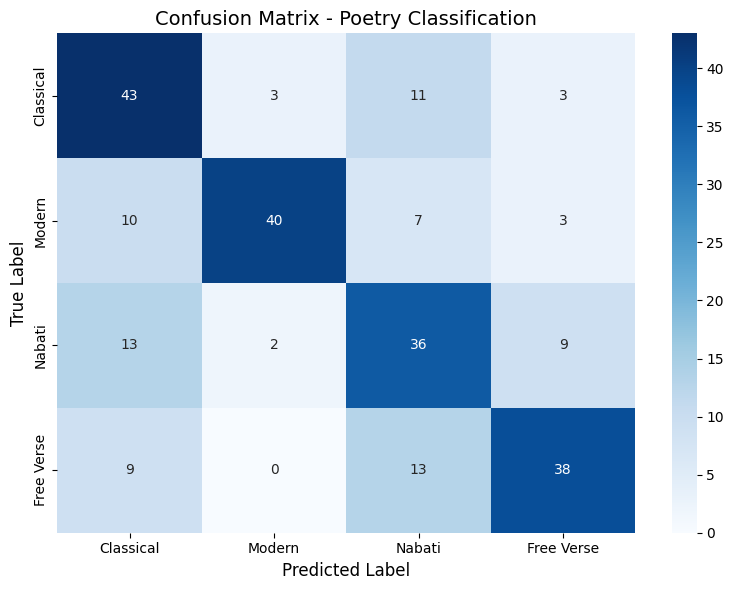

Overall Accuracy: 65.42%


In [82]:
# ====================================================
# SIMPLE CONFUSION MATRIX
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# After training, get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Define your class names
class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']  # Replace with your actual classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2%}")

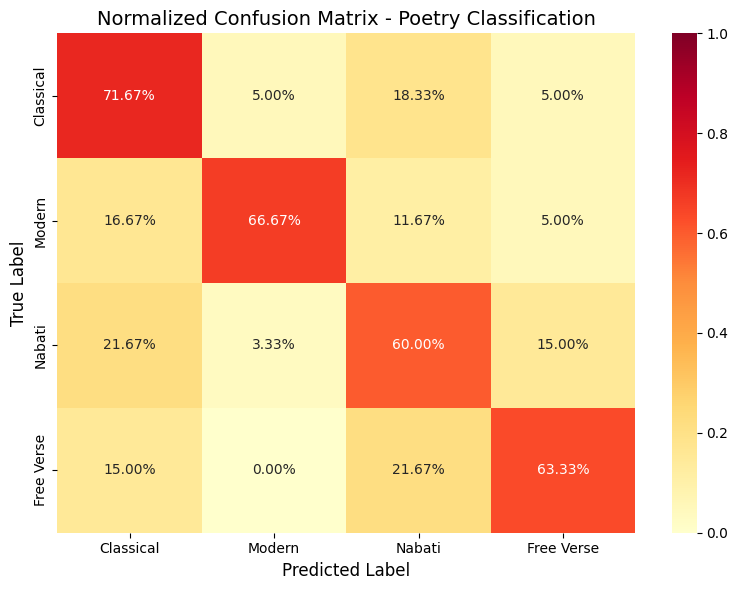

In [83]:
# ====================================================
# NORMALIZED CONFUSION MATRIX (Shows percentages)
# ====================================================

# Normalize by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

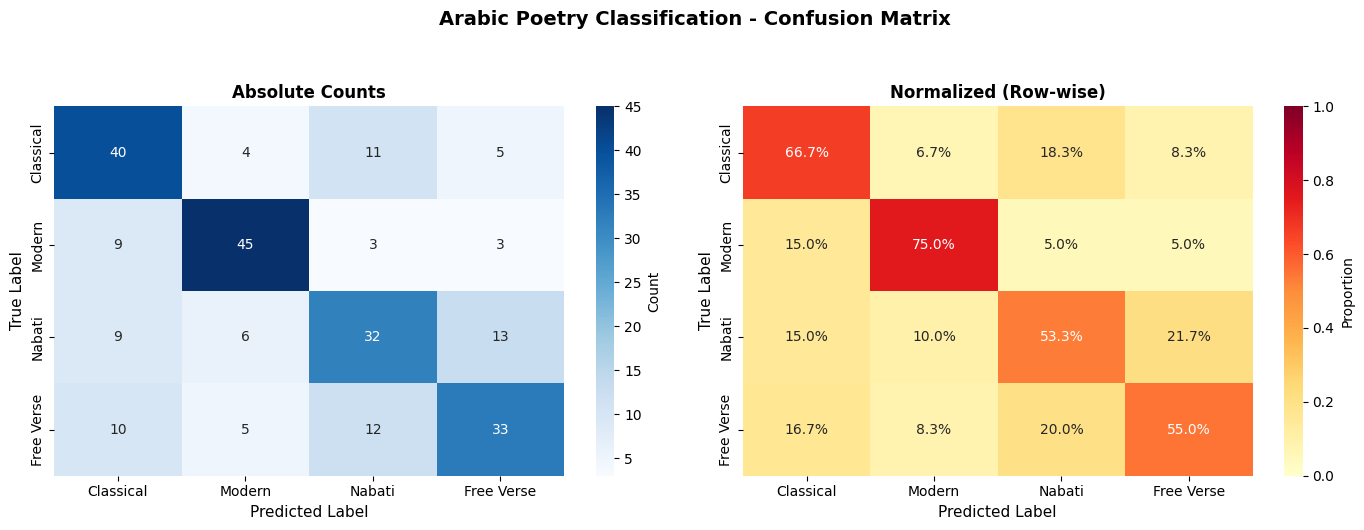


📊 Overall Accuracy: 62.50%

📈 Per-class Metrics:

Classical:
  Accuracy: 66.67%
  Precision: 58.82%
  Recall: 66.67%
  F1-Score: 62.50%

Modern:
  Accuracy: 75.00%
  Precision: 75.00%
  Recall: 75.00%
  F1-Score: 75.00%

Nabati:
  Accuracy: 53.33%
  Precision: 55.17%
  Recall: 53.33%
  F1-Score: 54.24%

Free Verse:
  Accuracy: 55.00%
  Precision: 61.11%
  Recall: 55.00%
  F1-Score: 57.89%


In [78]:
# ====================================================
# PUBLICATION-READY CONFUSION MATRIX
# ====================================================

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """
    Create a beautiful confusion matrix with multiple visualizations
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create figure with subplots
    fig = plt.figure(figsize=(14, 5))
    
    # 1. Absolute counts matrix
    ax1 = plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=ax1)
    ax1.set_xlabel('Predicted Label', fontsize=11)
    ax1.set_ylabel('True Label', fontsize=11)
    ax1.set_title('Absolute Counts', fontsize=12, fontweight='bold')
    
    # 2. Normalized matrix
    ax2 = plt.subplot(1, 2, 2)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
    ax2.set_xlabel('Predicted Label', fontsize=11)
    ax2.set_ylabel('True Label', fontsize=11)
    ax2.set_title('Normalized (Row-wise)', fontsize=12, fontweight='bold')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    accuracy = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"\n📊 Overall Accuracy: {accuracy:.2%}")
    
    print("\n📈 Per-class Metrics:")
    for i, name in enumerate(class_names):
        acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
        recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n{name}:")
        print(f"  Accuracy: {acc:.2%}")
        print(f"  Precision: {precision:.2%}")
        print(f"  Recall: {recall:.2%}")
        print(f"  F1-Score: {f1:.2%}")

# Use it
plot_confusion_matrix(y_true, y_pred, class_names, 
                     title='Arabic Poetry Classification - Confusion Matrix')

In [62]:
df_sampled11["poem"]

6330     وليلة يصطلي بالفرث جازرها يختص بالنقرى المثرين...
6331     وليلة يصطلي بالفرث جازرها يختص بالنقرى المثرين...
6332     لا ينبح الكلب فيها غير واحدة من العشاء ولا تسر...
6333     لا ينبح الكلب فيها غير واحدة من العشاء ولا تسر...
6560     يا مي إن تفقدي قوما ولدتهم أو تخلسيهم فإن الده...
                               ...                        
83481    ولها غدائر قد علون مأكما يغذى العبير أثيثها وس...
83482     ولها كهمك مقلتان وسنة وبها يضاء من الدجى إعتامها
83483    صفراء تصبح كالعرارة زادها حسنا إذا ارتفع الضحا...
83484       تجلو بأفنان أغر مفلجا يجري عليه أراكها وبشامها
83485    ريفا يرف كالأقحوان أصابه من صوب غادية الربيع ر...
Name: poem, Length: 2500, dtype: object

In [74]:
val_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 240
})

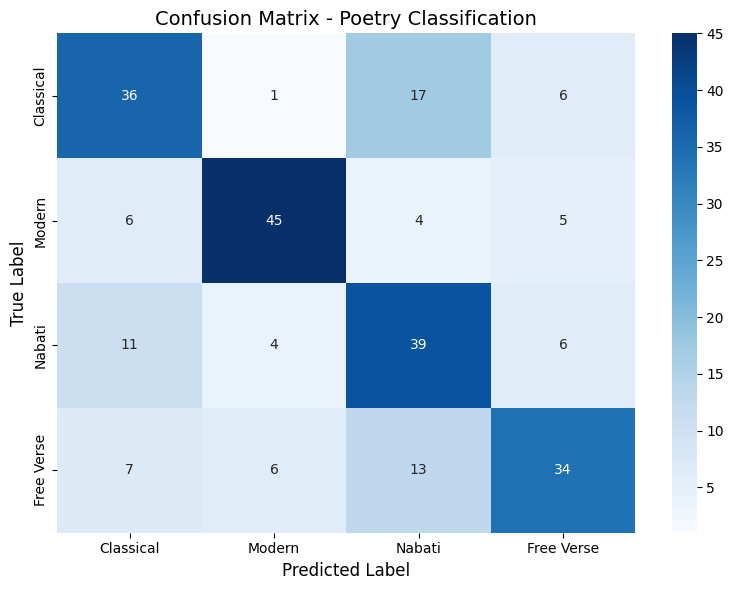

Overall Accuracy: 64.17%


In [73]:
# ====================================================
# SIMPLE CONFUSION MATRIX
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# After training, get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Define your class names
class_names = ['Classical', 'Modern', 'Nabati', 'Free Verse']  # Replace with your actual classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Print accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2%}")